## 1. 라이브러리 임포트

In [1]:
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from datetime import datetime
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models as tv_models
from torchmetrics import F1Score, Accuracy, AUROC, ConfusionMatrix
from torchmetrics.classification import MulticlassCohenKappa
from sklearn.metrics import classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {DEVICE}')
print('라이브러리 임포트 완료')


/home/user3/.conda/envs/G-kwr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


사용 디바이스: cuda
라이브러리 임포트 완료


## 2. ConvNeXtEmotionModel 클래스 정의

In [2]:
class ConvNeXtEmotionModel(nn.Module):
    """restart2.ipynb 와 동일한 구조 (ConvNeXt-Base v7)"""
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = tv_models.convnext_base(weights=None)
        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

print('ConvNeXtEmotionModel 클래스 정의 완료')


ConvNeXtEmotionModel 클래스 정의 완료


## 3. 경로 및 설정

In [3]:
DATA_DIR  = Path('/workspace/shared/data/processed/data_processed_v6')
RUN_ID    = datetime.now().strftime('%m%d_%H%M')
SAVE_DIR  = Path(f'/workspace/user3/out/ensemble_model_{RUN_ID}')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CLASSES     = ['anger', 'happy', 'panic', 'sadness']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 64
USE_AMP     = True
AMP_DTYPE   = torch.bfloat16

# Top-3 모델 설정
TOP3_CONFIGS = {
    'EfficientNetV2-M': {
        'ckpt'    : '/workspace/user3/out/checkpoints_efficientnetV2-M_0423_0640/efficientnet_best.pth',
        'json'    : '/workspace/user3/out/checkpoints_efficientnetV2-M_0423_0640/efficientnet_result.json',
        'timm'    : 'tf_efficientnetv2_m',
    },
    'MaxViT-Base': {
        'ckpt'    : '/workspace/user3/out/checkpoints_maxvit_0423_0147/maxvit_base_best.pth',
        'json'    : '/workspace/user3/out/checkpoints_maxvit_0423_0147/maxvit_result.json',
        'timm'    : 'maxvit_base_tf_224',
    },
    'ConvNeXt-Base v7': {
        'ckpt'     : '/workspace/user1/models/Best_convnext7.pth',
        'json'     : None,
        'timm'     : None,
        'accuracy' : 89.84,
    },
}

for name, cfg in TOP3_CONFIGS.items():
    if cfg['json'] is None:
        print(f'  {name:20s}: Accuracy {cfg["accuracy"]}%  (직접 설정)')
    else:
        with open(cfg['json']) as f:
            cfg['accuracy'] = json.load(f)['accuracy']
        print(f'  {name:20s}: Accuracy {cfg["accuracy"]}%')

print(f'\n저장 위치: {SAVE_DIR}')
print(f'Top-3 모델: {list(TOP3_CONFIGS.keys())}')


  EfficientNetV2-M    : Accuracy 88.54%
  MaxViT-Base         : Accuracy 87.97%
  ConvNeXt-Base v7    : Accuracy 89.84%  (직접 설정)

저장 위치: /workspace/user3/out/ensemble_model_0430_0835
Top-3 모델: ['EfficientNetV2-M', 'MaxViT-Base', 'ConvNeXt-Base v7']


## 4. 앙상블 모델 클래스 정의

In [4]:
class Top3EnsembleModel(nn.Module):
    # FGI 감정 분류 Top-3 앙상블 모델
    # EfficientNetV2-M + MaxViT-Base + ConvNeXt-Base-v7 소프트맥스 평균
    def __init__(self, num_classes=4):
        super().__init__()
        self.num_classes = num_classes
        self.model_names = ['EfficientNetV2-M', 'MaxViT-Base', 'ConvNeXt-Base-v7']

        self.efficientnet = timm.create_model(
            'tf_efficientnetv2_m', pretrained=False, num_classes=num_classes
        )
        self.maxvit = timm.create_model(
            'maxvit_base_tf_224', pretrained=False, num_classes=num_classes
        )
        self.convnext_v7 = ConvNeXtEmotionModel(num_classes=num_classes)

    def forward(self, x):
        p1 = torch.softmax(self.efficientnet(x), dim=1)
        p2 = torch.softmax(self.maxvit(x), dim=1)
        p3 = torch.softmax(self.convnext_v7(x), dim=1)
        return (p1 + p2 + p3) / 3

    @classmethod
    def load(cls, ckpt_path, device=None):
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = cls()
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.to(device)
        model.eval()
        return model

print('Top3EnsembleModel 클래스 정의 완료')


Top3EnsembleModel 클래스 정의 완료


## 5. 개별 가중치 로드 후 앙상블 모델에 통합

In [5]:
print('앙상블 모델 구성 중...')
ensemble = Top3EnsembleModel(num_classes=NUM_CLASSES).to(DEVICE)

sub_models = {
    'efficientnet' : ensemble.efficientnet,
    'maxvit'       : ensemble.maxvit,
    'convnext_v7'  : ensemble.convnext_v7,
}
ckpts = [
    TOP3_CONFIGS['EfficientNetV2-M']['ckpt'],
    TOP3_CONFIGS['MaxViT-Base']['ckpt'],
    TOP3_CONFIGS['ConvNeXt-Base v7']['ckpt'],
]

for (sub_name, sub_model), ckpt in zip(sub_models.items(), ckpts):
    print(f'  [{sub_name}] 가중치 로드 중...')
    sub_model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    sub_model.eval()
    params = sum(p.numel() for p in sub_model.parameters())
    print(f'    완료: {params:,} params')

ensemble.eval()
total_params = sum(p.numel() for p in ensemble.parameters())
print(f'\n앙상블 모델 총 파라미터: {total_params:,}')
print('앙상블 모델 구성 완료!')


앙상블 모델 구성 중...
  [efficientnet] 가중치 로드 중...
    완료: 52,863,480 params
  [maxvit] 가중치 로드 중...
    완료: 118,701,784 params
  [convnext_v7] 가중치 로드 중...
    완료: 87,570,564 params

앙상블 모델 총 파라미터: 259,135,828
앙상블 모델 구성 완료!


## 6. 앙상블 모델 검증 (테스트셋 평가)

> 저장 전에 평가를 먼저 실행해서 모든 지표를 config에 저장합니다.

In [6]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

f1_metric    = F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro')
top2_metric  = Accuracy(task='multiclass', num_classes=NUM_CLASSES, top_k=2)
auroc_metric = AUROC(task='multiclass', num_classes=NUM_CLASSES)
kappa_metric = MulticlassCohenKappa(num_classes=NUM_CLASSES)

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='테스트셋 평가'):
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            probs = ensemble(imgs)
        probs  = probs.float().cpu()
        preds  = probs.argmax(dim=1)
        all_preds.append(preds); all_labels.append(labels); all_probs.append(probs)
        f1_metric.update(preds, labels)
        top2_metric.update(probs, labels)
        auroc_metric.update(probs, labels)
        kappa_metric.update(preds, labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
acc        = (all_preds == all_labels).float().mean().item()

result_f1    = f1_metric.compute().item()
result_top2  = top2_metric.compute().item()
result_auroc = auroc_metric.compute().item()
result_kappa = kappa_metric.compute().item()

print(f'\n===== Top-3 Ensemble 최종 검증 =====')
print(f'Accuracy     : {acc*100:.2f}%')
print(f'Top-2 Acc    : {result_top2*100:.2f}%')
print(f'F1 Score     : {result_f1:.4f}')
print(f'ROC-AUC      : {result_auroc:.4f}')
print(f"Cohen's Kappa: {result_kappa:.4f}")
print('\n분류 리포트:')
print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=CLASSES))


테스트셋 평가: 100%|██████████| 11/11 [00:14<00:00,  1.32s/it]


===== Top-3 Ensemble 최종 검증 =====
Accuracy     : 90.54%
Top-2 Acc    : 97.28%
F1 Score     : 0.9053
ROC-AUC      : 0.9805
Cohen's Kappa: 0.8739

분류 리포트:
              precision    recall  f1-score   support

       anger       0.91      0.88      0.90       175
       happy       0.92      0.97      0.95       172
       panic       0.91      0.87      0.89       173
     sadness       0.88      0.90      0.89       178

    accuracy                           0.91       698
   macro avg       0.91      0.91      0.91       698
weighted avg       0.91      0.91      0.91       698



## 7. 앙상블 모델 저장 (평가 지표 포함)

In [7]:
# 모델 가중치 저장
ckpt_path = SAVE_DIR / 'ensemble_top3_best.pth'
torch.save(ensemble.state_dict(), str(ckpt_path))
print(f'모델 저장 완료: {ckpt_path}')

# 모든 지표 포함해서 config 저장
config = {
    'model_type'    : 'Top3EnsembleModel',
    'models'        : list(TOP3_CONFIGS.keys()),
    'num_classes'   : NUM_CLASSES,
    'classes'       : CLASSES,
    'img_size'      : IMG_SIZE,
    'accuracy'      : round(acc * 100, 2),
    'top2_accuracy' : round(result_top2 * 100, 2),
    'f1_score'      : round(result_f1, 4),
    'roc_auc'       : round(result_auroc, 4),
    'cohen_kappa'   : round(result_kappa, 4),
    'params'        : sum(p.numel() for p in ensemble.parameters()),
    'epochs'        : 'N/A',
    'created_at'    : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'individual_accuracy': {k: v['accuracy'] for k, v in TOP3_CONFIGS.items()},
}
config_path = SAVE_DIR / 'ensemble_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(f'Config 저장 완료: {config_path}')

print('\n===== 저장된 파일 =====')
for f in sorted(SAVE_DIR.iterdir()):
    print(f'  {f.name:<40s} {f.stat().st_size/1e6:.1f} MB')


모델 저장 완료: /workspace/user3/out/ensemble_model_0430_0835/ensemble_top3_best.pth
Config 저장 완료: /workspace/user3/out/ensemble_model_0430_0835/ensemble_config.json

===== 저장된 파일 =====
  ensemble_config.json                     0.0 MB
  ensemble_top3_best.pth                   1039.4 MB


## 8. 로드 테스트

> 저장된 모델을 다시 불러와서 동작하는지 확인합니다.

In [8]:
print('저장된 앙상블 모델 로드 테스트...')

del ensemble
torch.cuda.empty_cache()

loaded_ensemble = Top3EnsembleModel.load(str(ckpt_path), device=DEVICE)
print(f'로드 완료!')

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = loaded_ensemble(dummy)
print(f'출력 shape: {out.shape}  (배치=2, 클래스=4)')
print(f'확률 합계: {out.sum(dim=1)}  (각 행의 합이 1이면 정상)')
print('\n앙상블 모델 저장/로드 완료!')
print(f'\n저장 위치: {SAVE_DIR}')
print(f'  ensemble_top3_best.pth  <- 모델 가중치')
print(f'  ensemble_config.json    <- 모델 구성 및 전체 지표')


저장된 앙상블 모델 로드 테스트...
로드 완료!
출력 shape: torch.Size([2, 4])  (배치=2, 클래스=4)
확률 합계: tensor([1., 1.], device='cuda:0')  (각 행의 합이 1이면 정상)

앙상블 모델 저장/로드 완료!

저장 위치: /workspace/user3/out/ensemble_model_0430_0835
  ensemble_top3_best.pth  <- 모델 가중치
  ensemble_config.json    <- 모델 구성 및 전체 지표


## 9. 혼동행렬 및 클래스별 정확도 시각화

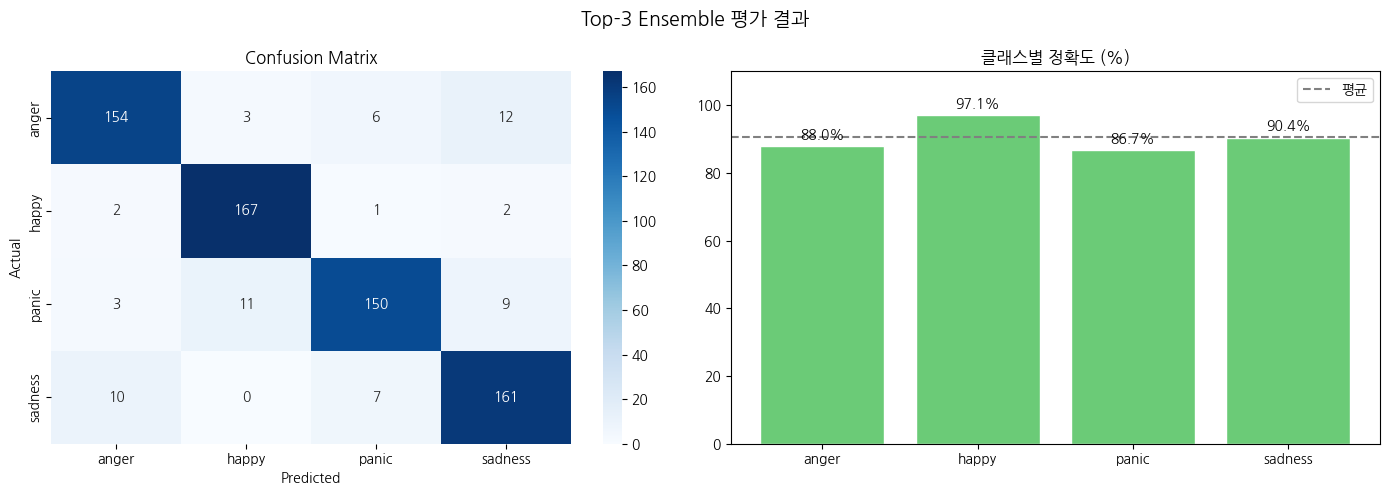

시각화 저장 완료


In [9]:
cm_metric = ConfusionMatrix(task='multiclass', num_classes=NUM_CLASSES)
cm_metric.update(all_preds, all_labels)
cm = cm_metric.compute().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top-3 Ensemble 평가 결과', fontsize=14)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

class_acc = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['#FF6B6B' if a < 70 else '#6BCB77' for a in class_acc]
bars = axes[1].bar(CLASSES, class_acc, color=colors, edgecolor='white')
axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1].axhline(y=sum(class_acc)/len(class_acc), color='gray', linestyle='--', label='평균')
axes[1].set_title('클래스별 정확도 (%)')
axes[1].set_ylim(0, 110); axes[1].legend()

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'ensemble_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('시각화 저장 완료')


## 9. 전체 모델 성능 비교

=== 최종 모델 성능 비교 (전체) ===
              모델 Accuracy Top-2 Acc F1 Score ROC-AUC Cohen's Kappa      파라미터 수 학습 에폭
EfficientNetV2-M   88.54%    95.99%   0.8854  0.9734        0.8472  52,863,480    32
Swin Transformer   87.11%    96.85%   0.8718  0.9663        0.8281  86,747,324    14
   ConvNeXt-Base   84.10%    96.13%   0.8394  0.9672        0.7879  87,570,564    10
   DeiT III-Base   86.10%    96.28%   0.8617  0.9672        0.8147  85,819,396    17
     MaxViT-Base   87.97%    95.27%   0.8790  0.9667        0.8395 118,701,784    15
       ViT-Large   85.39%    96.13%   0.8528  0.9652        0.8052 303,305,732    13
  ConvNeXt-Large   87.39%    97.42%   0.8741  0.9738        0.8319 196,236,484    14
       Basic CNN   65.90%    86.53%   0.6535  0.8591        0.5455     422,788    50
   Custom CNN v1   83.52%    95.56%   0.8342  0.9550        0.7803  28,367,420    53
   Custom CNN v3   86.82%    95.99%   0.8664  0.9638        0.8242  28,367,420   131
     Ensemble v2   90.69%    97.42%   0.

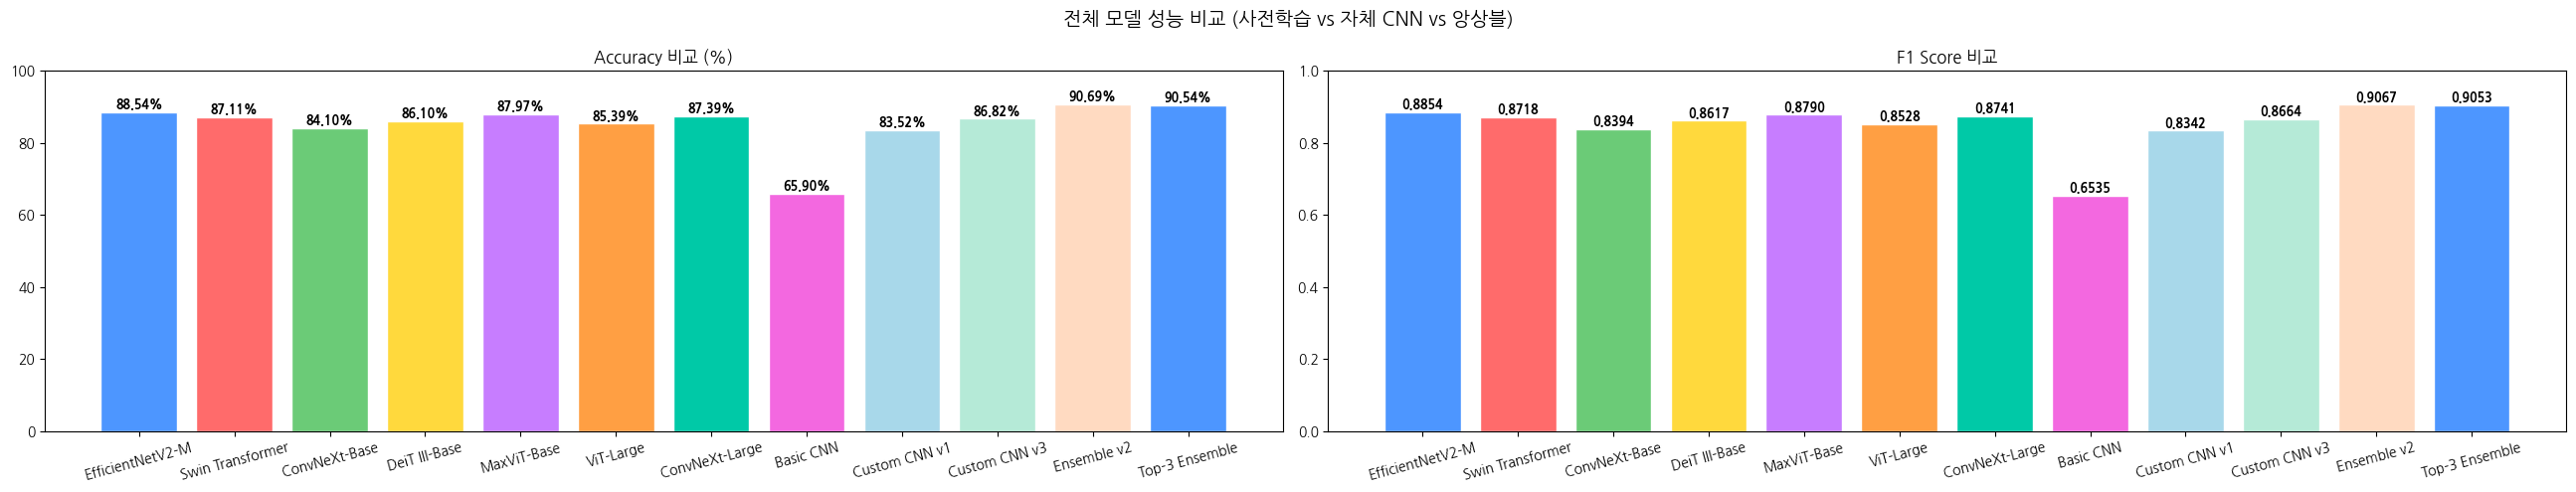

비교 시각화 저장 완료


In [11]:
results = {}
model_paths = {
    "EfficientNetV2-M": Path("/workspace/user3/out/checkpoints_efficientnetV2-M_0423_0640") / "efficientnet_result.json",
    "Swin Transformer": Path("/workspace/user3/out/checkpoints_swin_0423_0626")             / "swin_result.json",
    "ConvNeXt-Base"   : Path("/workspace/user3/out/checkpoints_convnext_0423_0817")         / "convnext_result.json",
    "DeiT III-Base"   : Path("/workspace/user3/out/checkpoints_deit3_0423_0112")            / "deit3_result.json",
    "MaxViT-Base"     : Path("/workspace/user3/out/checkpoints_maxvit_0423_0147")           / "maxvit_result.json",
    "ViT-Large"       : Path("/workspace/user3/out/checkpoints_vit_large_0423_0233")        / "vit_large_result.json",
    "ConvNeXt-Large"  : Path("/workspace/user3/out/checkpoints_convnext_large_0423_0425")   / "convnext_large_result.json",
    "Basic CNN"       : Path("/workspace/user3/out/checkpoints_basiccnn_0424_0635")         / "basiccnn_result.json",
    "Custom CNN v1"   : Path("/workspace/user3/out/checkpoints_customcnn_0427_0208")        / "customcnn_result.json",
    "Custom CNN v3"   : Path("/workspace/user3/out/checkpoints_customcnn_v3_0429_0441")     / "customcnn_v3_result.json",  # 폴더명 수정
    "Ensemble v2"     : Path("/workspace/user3/out/ensemble_model_0429_0710")               / "ensemble_config.json"
}

for model_name, path in model_paths.items():
    if path.exists():
        with open(path) as f:
            results[model_name] = json.load(f)
    else:
        print(f"  [{model_name}] 없음 -> 해당 노트북을 먼저 실행하세요.")
        results[model_name] = {"accuracy": 0, "top2_accuracy": 0, "f1_score": 0,
                               "roc_auc": 0, "cohen_kappa": 0, "params": 0, "epochs": "N/A"}

# 앙상블은 방금 저장한 config_path에서 바로 로드
with open(config_path) as f:
    results["Top-3 Ensemble"] = json.load(f)

comparison = pd.DataFrame({
    "모델"          : list(results.keys()),
    "Accuracy"      : [f"{v['accuracy']:.2f}%"                                          for v in results.values()],
    "Top-2 Acc"     : [f"{v['top2_accuracy']:.2f}%" if "top2_accuracy" in v else "N/A"  for v in results.values()],
    "F1 Score"      : [f"{v['f1_score']:.4f}"                                           for v in results.values()],
    "ROC-AUC"       : [f"{v['roc_auc']:.4f}"        if "roc_auc"       in v else "N/A"  for v in results.values()],
    "Cohen's Kappa" : [f"{v['cohen_kappa']:.4f}"    if "cohen_kappa"   in v else "N/A"  for v in results.values()],
    "파라미터 수"    : [f"{v['params']:,}"           if "params"        in v else "N/A"  for v in results.values()],
    "학습 에폭"      : [str(v.get("epochs", "N/A"))                                       for v in results.values()],
})
print("=== 최종 모델 성능 비교 (전체) ===")
print(comparison.to_string(index=False))

model_names = list(results.keys())
accs = [results[m]["accuracy"] for m in model_names]
f1s  = [results[m]["f1_score"] for m in model_names]
colors = ["#4D96FF","#FF6B6B","#6BCB77","#FFD93D","#C77DFF","#FF9F43","#00C9A7",
          "#F368E0","#A8D8EA","#B5EAD7","#FFDAC1"]

fig, axes = plt.subplots(1, 2, figsize=(26, 5))
fig.suptitle("전체 모델 성능 비교 (사전학습 vs 자체 CNN vs 앙상블)", fontsize=14)

axes[0].bar(model_names, accs, color=colors[:len(model_names)], edgecolor="white")
axes[0].set_title("Accuracy 비교 (%)"); axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(axes[0].patches, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.2f}%", ha="center", fontweight="bold", fontsize=9)

axes[1].bar(model_names, f1s, color=colors[:len(model_names)], edgecolor="white")
axes[1].set_title("F1 Score 비교"); axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis="x", rotation=15)
for bar, val in zip(axes[1].patches, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "model_comparison_all.png"), dpi=150, bbox_inches="tight")
plt.show()
print("비교 시각화 저장 완료")
